In [1]:
# Standard library
import argparse
import csv
import itertools
import os
import random
import sys
from collections import Counter

# Add project path
sys.path.insert(0, '/hkfs/work/workspace/scratch/cc7738-automorphism/ANP4Link')

# Third-party libraries
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from torch import Tensor
from scipy.sparse.linalg import eigsh
from scipy.stats import qmc

# PyTorch Geometric
from torch_geometric.datasets import Amazon, Planetoid
from torch_geometric.nn import WLConv
from torch_geometric.typing import Adj
from torch_geometric.utils import (
    degree,
    from_networkx,
    is_sparse,
    scatter,
    sort_edge_index,
    to_edge_index,
    to_undirected,
    train_test_split_edges,
)

# OGB
from ogb.linkproppred import PygLinkPropPredDataset

# Project-specific modules
from syn_graph.graph_generation import GraphType, generate_graph
from syn_graph.syn_random import RegularTilling, init_regular_tilling

from syn_real.custom_wl import WLConvOptimized
from syn_real.measure import hash_links_by_orbit
from syn_real.plotting import plot_orbit_dist, plot_orbit_histogram

/home/hk-project-test-p0021478/cc7738/anaconda3/envs/EAsF/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def run_wl_test_and_group_nodes(edge_index, num_nodes, num_iterations=1000):
    """
    Runs the Weisfeiler-Lehman (WL) test and groups nodes with similar hashed labels.
    
    Args:
        edge_index (Tensor): The edge index tensor (2, |E|) representing the graph.
        num_nodes (int): The number of nodes in the graph.
        num_iterations (int): Number of WL iterations.
    
    Returns:
        node_groups (dict): Mapping from WL hashes to node sets.
        node_labels (Tensor): Final hashed labels for each node.
    """
    # wl = WLConvMultiFeature()  
    wl = WLConvOptimized()  

    node_labels = np.ones(num_nodes)
    for _ in range(num_iterations):
        node_labels = wl(node_labels, edge_index)  
    # Group nodes based on final hashed values
    node_groups = {}
    for node, label in enumerate(node_labels.tolist()):
        if label not in node_groups:
            node_groups[label] = []
        node_groups[label].append(node)
    _, new_labels = torch.unique(node_labels, return_inverse=True)
    return node_groups, node_labels, new_labels

In [3]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter


def create_orbit_labels(G, orbits):
    """
    Generate a mapping from each node in G to its orbit label.
    """
    if type(orbits) is torch.Tensor:
        orbits = orbits.tolist()
    return {node: str(orbits[idx]) for idx, node in enumerate(G.nodes())}


def plot_colored_graph(G, pos, labels, orbits, ax):
    """
    Plot the graph G colored by orbit labels on the given axis.
    """
    node_colors = [orbits[node] for node in G.nodes()]
    nx.draw(
        G,
        pos=pos,
        labels=labels,
        node_color=node_colors,
        cmap='tab20b',
        node_size=500,
        font_weight='bold',
        edgecolors='black',
        ax=ax
    )
    ax.set_title("Graph Colored by Orbit Labels")


def plot_degree_distribution(G, ax):
    """
    Plot the degree distribution of G as a stem plot.
    """
    degrees = sorted((d for _, d in G.degree()), reverse=True)
    markerline, stemlines, _ = ax.stem(degrees, markerfmt='bo', basefmt=' ')
    markerline.set_markerfacecolor('none')
    stemlines.set_linewidth(0.5)
    ax.set_xlabel("Degree")
    ax.set_ylabel("Frequency")
    ax.set_title("Degree Distribution")


def plot_orbit_histogram(orbits, ax):
    """
    Plot a sorted histogram of orbit sizes.
    """
    counts = Counter(orbits.tolist())
    sizes = sorted(counts.values(), reverse=True)
    markerline, stemlines, _ = ax.stem(sizes, markerfmt='bo', basefmt=' ')
    markerline.set_markerfacecolor('none')
    stemlines.set_linewidth(0.5)
    ax.set_xlabel("Orbit Index")
    ax.set_ylabel("Orbit Size")
    ax.set_title("Sorted Orbit Size")
    ax.grid(axis='y', linestyle='--', alpha=0.7)


def plot_edge_distribution(G, orbits, ax):
    """
    Plot the automorphic edge class distribution as a stem plot.
    """
    _, edge_class_counts = hash_links_by_orbit(G, orbits)
    markerline, stemlines, _ = ax.stem(edge_class_counts, markerfmt='bo', basefmt=' ')
    markerline.set_markerfacecolor('none')
    stemlines.set_linewidth(0.5)
    ax.set_title('Automorphic Edge Distribution')
    ax.set_xlabel("Automorphism Edge Classes")
    ax.set_ylabel("Frequency")


def plot_orbit_analysis(G, pos, orbits, figsize=(18, 6)):
    """
    Create a 1x4 subplot figure showing:
      1) Graph colored by orbits
      2) Degree distribution
      3) Sorted orbit size histogram
      4) Automorphic edge distribution

    Parameters:
    - G: networkx.Graph
    - pos: dict mapping nodes to positions
    - orbits: array-like of orbit labels aligned with G.nodes()
    - figsize: tuple for figure size
    """
    labels = create_orbit_labels(G, orbits)
    fig, axes = plt.subplots(1, 4, figsize=figsize)

    plot_colored_graph(G, pos, labels, orbits, axes[0])
    plot_degree_distribution(G, axes[1])
    plot_orbit_histogram(orbits, axes[2])
    plot_edge_distribution(G, orbits, axes[3])

    plt.tight_layout()
    plt.show()

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

def generate_watts_strogatz(n, k, p):
    """
    Generate a Watts–Strogatz small-world network.

    Parameters:
    - n (int): number of nodes
    - k (int): each node is joined with its k nearest neighbors in ring topology (k must be even)
    - p (float): probability of rewiring each edge

    Returns:
    - G (networkx.Graph): the generated WS graph
    """
    return nx.watts_strogatz_graph(n, k, p)

def plot_graph(G, title="Watts–Strogatz Graph"):
    """
    Plot the provided NetworkX graph.

    Parameters:
    - G (networkx.Graph): the graph to plot
    - title (str): title of the plot
    """
    pos = nx.circular_layout(G)
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_size=300, font_size=8)
    plt.title(title)
    plt.show()

def compute_metrics(G):
    """
    Compute and return some standard small-world metrics:
    - average clustering coefficient
    - average shortest path length (only if the graph is connected)

    Returns:
    - metrics (dict)
    """
    clustering = nx.average_clustering(G)
    if nx.is_connected(G):
        path_length = nx.average_shortest_path_length(G)
    else:
        # take the largest connected component
        largest_cc = max(nx.connected_components(G), key=len)
        subG = G.subgraph(largest_cc)
        path_length = nx.average_shortest_path_length(subG)
    return {
        "avg_clustering": clustering,
        "avg_shortest_path": path_length
    }



In [5]:
def plot_orbit_analysis(G, pos, orbits, figsize=(18, 6)):
    """
    Create a 1x4 subplot figure showing:
      1) Graph colored by orbits
      2) Degree distribution
      3) Sorted orbit size histogram
      4) Automorphic edge distribution

    Parameters:
    - G: networkx.Graph
    - pos: dict mapping nodes to positions
    - orbits: array-like of orbit labels aligned with G.nodes()
    - figsize: tuple for figure size
    """
    labels = create_orbit_labels(G, orbits)
    fig, axes = plt.subplots(1, 4, figsize=figsize)

    plot_colored_graph(G, pos, labels, orbits, axes[0])
    plot_degree_distribution(G, axes[1])
    plot_orbit_histogram(orbits, axes[2])
    plot_edge_distribution(G, orbits, axes[3])

    plt.tight_layout()
    plt.show()


Average clustering coefficient: 0.4092
Average shortest path length:   7.1134


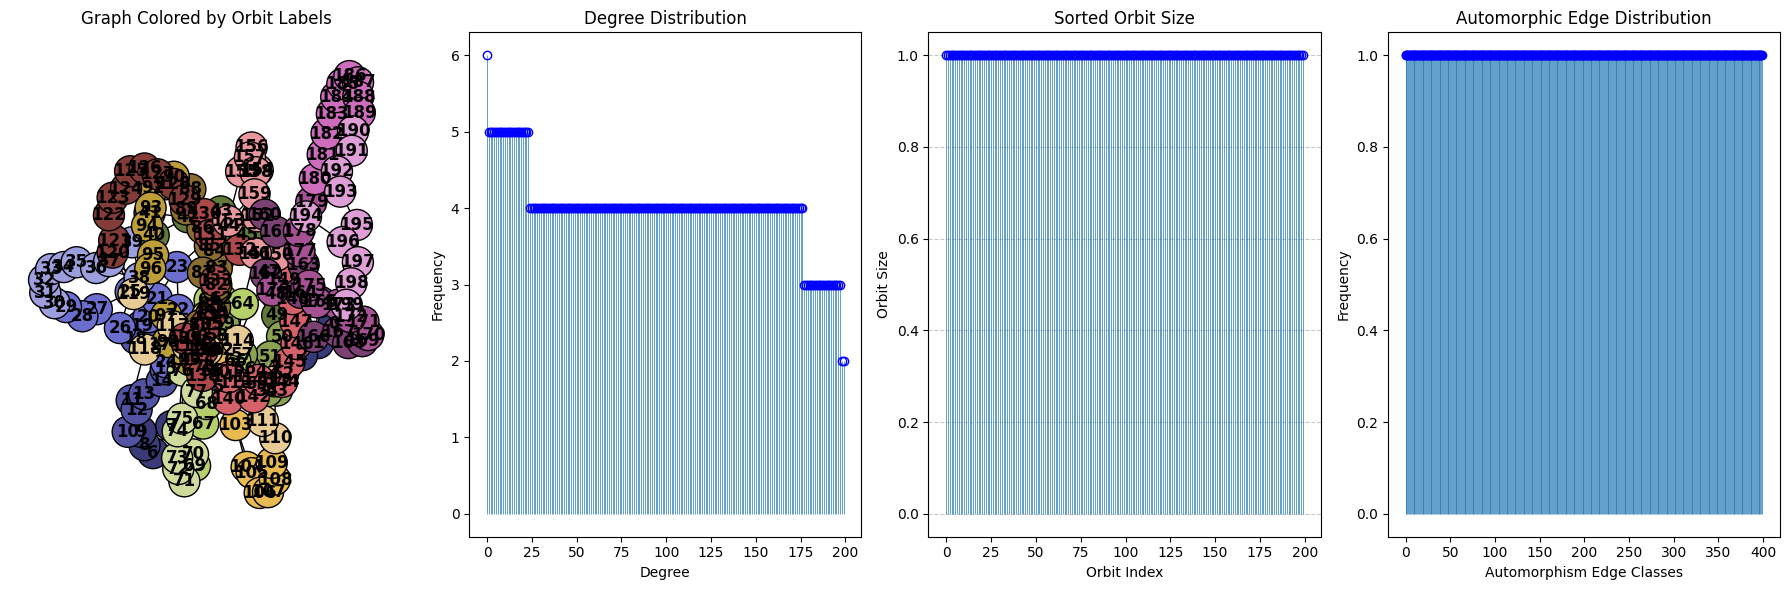

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def generate_chung_lu(degree_sequence):
    """
    Generate a Chung–Lu random graph with a given expected degree sequence.

    Parameters:
    - degree_sequence (list of floats): target expected degrees for each node

    Returns:
    - G (networkx.Graph): the generated Chung–Lu graph
    """
    # The expected_degree_graph function implements the Chung–Lu model
    G = nx.expected_degree_graph(degree_sequence, selfloops=False)
    return G

def compute_metrics(G):
    """
    Compute and return some standard graph metrics:
    - average clustering coefficient
    - average shortest path length (using the largest connected component if necessary)

    Returns:
    - metrics (dict)
    """
    clustering = nx.average_clustering(G)
    if nx.is_connected(G):
        path_length = nx.average_shortest_path_length(G)
    else:
        # restrict to the largest connected component
        largest_cc = max(nx.connected_components(G), key=len)
        subG = G.subgraph(largest_cc)
        path_length = nx.average_shortest_path_length(subG)
    return {
        "avg_clustering": clustering,
        "avg_shortest_path": path_length
    }

def plot_graph(G, title="Chung–Lu Random Graph"):
    """
    Plot the provided NetworkX graph.

    Parameters:
    - G (networkx.Graph): the graph to plot
    - title (str): title of the plot
    """
    pos = nx.spring_layout(G)
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_size=100, font_size=8)
    plt.title(title)
    plt.show()

if __name__ == "__main__":

    # Example parameters
    n = 200   # number of nodes
    k = 4   # each node connected to 6 nearest neighbors
    p = 0.05    # rewiring probability

    # Generate the WS small-world graph
    G = generate_watts_strogatz(n, k, p)

    # Compute metrics
    metrics = compute_metrics(G)
    print(f"Average clustering coefficient: {metrics['avg_clustering']:.4f}")
    print(f"Average shortest path length:   {metrics['avg_shortest_path']:.4f}")

    data = from_networkx(G)
    edge_index = data.edge_index
    node_groups, node_labels, orbits = run_wl_test_and_group_nodes(edge_index, num_nodes=G.number_of_nodes(), num_iterations=100)
    
    custom_labels = {}
    for i, ov in zip(G.nodes(), orbits):
            custom_labels[i] = f"{ov}"

    plot_orbit_analysis(G, None, orbits)



IndexError: index 37 is out of bounds for dimension 0 with size 37

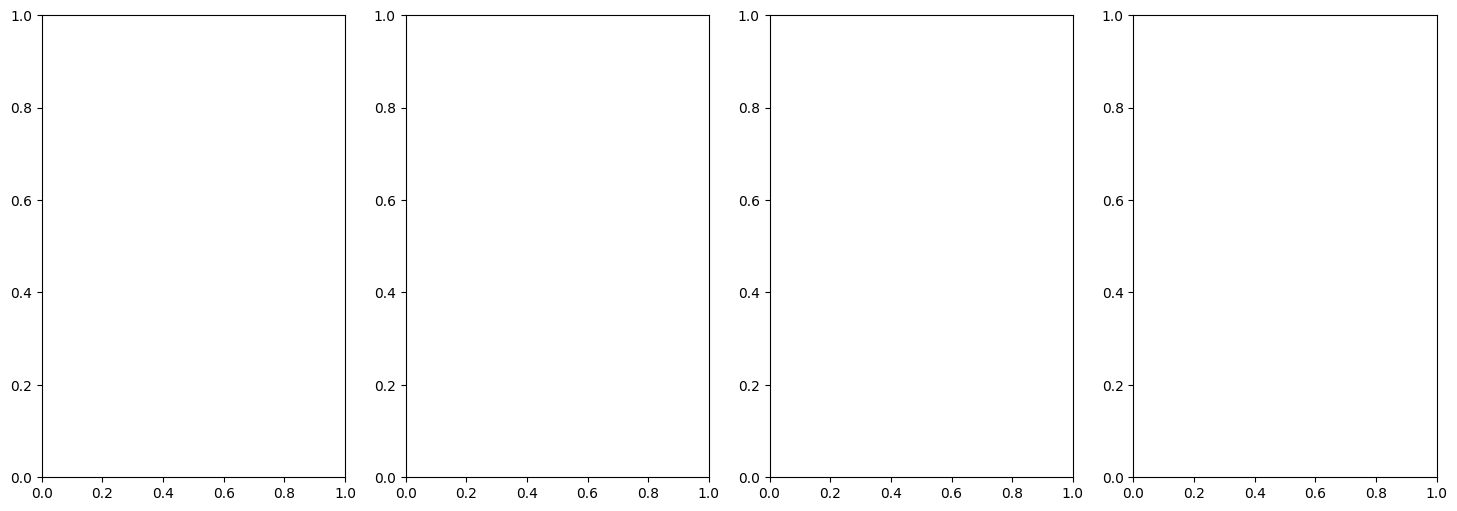

In [ ]:

# Example expected degree sequence
n = 50
import numpy as np
seq = np.random.zipf(a=2.0, size=n)
degree_sequence = [min(d, n-1) for d in seq]

# Generate the Chung–Lu graph
G = generate_chung_lu(degree_sequence)

G.remove_nodes_from(list(nx.isolates(G)))
data = from_networkx(G)
# 4. Compute positions for plotting
pos = nx.spring_layout(G, seed=42)

edge_index = data.edge_index
node_groups, node_labels, orbits = run_wl_test_and_group_nodes(edge_index, num_nodes=G.number_of_nodes(), num_iterations=100)

custom_labels = {}
for i, ov in zip(G.nodes(), orbits):
        custom_labels[i] = f"{ov}"
plot_orbit_analysis(G, pos, orbits)

